In [1]:
# Keep this as the first code cell for reproducibility.
STUDENT_NAME = "Nikhil Kanaparthi"
SID4 = 6441
SEED = 6441

SEQ_LEN = 128
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT = 0.10
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
EPOCHS = 6
MAX_NEW_TOKENS = 200

assert D_MODEL % N_HEADS == 0
assert N_HEADS >= 4
assert N_LAYERS >= 2
assert 5 <= EPOCHS <= 8

print("Student:", STUDENT_NAME)
print("SID4:", SID4)
print("Seed:", SEED)
print("Sequence length:", SEQ_LEN)
print("STEP 0: PASS")


Student: Nikhil Kanaparthi
SID4: 6441
Seed: 6441
Sequence length: 128
STEP 0: PASS


## 1. Setup

Google Colab already provides PyTorch, NumPy, pandas, and Matplotlib. We install only
`reportlab`, which is used at the end to create the findings PDF. Reinstalling PyTorch is
unnecessary and can damage the managed Colab environment.


In [2]:
%pip install -q reportlab
print("STEP 1: PASS")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.4 MB/s eta 0:00:00
STEP 1: PASS


In [3]:
import gc
import html
import json
import math
import os
import platform
import random
import subprocess
import sys
import textwrap
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from torch.utils.data import DataLoader, Dataset

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("hw4_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_LOG_LINES = []

def log(message):
    line = f"[{datetime.now(timezone.utc).isoformat()}] {message}"
    RUN_LOG_LINES.append(line)
    print(line)

log(f"Started HW4; SID4={SID4}; seed={SEED}; device={DEVICE}")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("NOTE: The notebook works on CPU, but a Colab T4 GPU is recommended.")
print("STEP 2: PASS")


[2026-09-22T21:23:14.118297+00:00] Started HW4; SID4=6441; seed=6441; device=cuda
Python: 3.13.15
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
STEP 2: PASS


## 2. Part 1 - Data preparation

### 2.1 Load the supplied Shakespeare text

The exact text supplied with the instructor's demo is embedded below as a fallback. If a
file named `shakespeare.txt` is present, the notebook reads that file. Otherwise, it uses the
embedded copy. This makes the notebook self-contained while preserving the assigned dataset.


In [4]:
SHAKESPEARE_FALLBACK = 'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the envious moon,\nWho is already sick and pale with grief,\nThat thou her maid art far more fair than she.\nBe not her maid, since she is envious;\nHer vestal livery is but sick and green,\nAnd none but fools do wear it; cast it off.\nIt is my lady, O, it is my love!\nO, that she knew she were!\nShe speaks yet she says nothing: what of that?\nHer eye discourses; I will answer it.\nI am too bold, ’tis not to me she speaks:\nTwo of the fairest stars in all the heaven,\nHaving some business, do entreat her eyes\nTo twinkle in their spheres till they return.\n\nJULIET:\nO Romeo, Romeo! wherefore art thou Romeo?\nDeny thy father and refuse thy name;\nOr, if thou wilt not, be but sworn my love,\nAnd I’ll no longer be a Capulet.\n\nROMEO:\nShall I hear more, or shall I speak at this?\n\nJULIET:\n’Tis but thy name that is my enemy;\nThou art thyself, though not a Montague.\nWhat’s Montague? it is nor hand, nor foot,\nNor arm, nor face, nor any other part\nBelonging to a man.\nO be some other name!\nWhat’s in a name? that which we call a rose\nBy any other word would smell as sweet;\nSo Romeo would, were he not Romeo call’d,\nRetain that dear perfection which he owes\nWithout that title.\nRomeo, doff thy name;\nAnd for that name which is no part of thee\nTake all myself.\n\nROMEO:\nI take thee at thy word:\nCall me but love, and I’ll be new baptized;\nHenceforth I never will be Romeo.\n\nJULIET:\nWhat man art thou that thus bescreen’d in night\nSo stumblest on my counsel?\n\nROMEO:\nBy a name\nI know not how to tell thee who I am:\nMy name, dear saint, is hateful to myself,\nBecause it is an enemy to thee;\nHad I it written, I would tear the word.'

dataset_path = Path("shakespeare.txt")
if dataset_path.exists():
    text = dataset_path.read_text(encoding="utf-8").strip()
    DATA_SOURCE = "uploaded shakespeare.txt"
else:
    text = SHAKESPEARE_FALLBACK.strip()
    DATA_SOURCE = "embedded copy of the supplied shakespeare.txt"

assert len(text) > SEQ_LEN + 1
assert text.startswith("ROMEO:")
print("Data source:", DATA_SOURCE)
print("Total characters:", len(text))
print("Preview:\n", text[:300])
print("STEP 3: PASS")


Data source: embedded copy of the supplied shakespeare.txt
Total characters: 1737
Preview:
 ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she is envious;
Her vestal livery is but sick a
STEP 3: PASS


### 2.2 Character-level tokenization

Each distinct character receives one integer ID. `char_to_idx` encodes text and
`idx_to_char` decodes IDs back to readable text.


In [5]:
characters = sorted(set(text))
vocab_size = len(characters)
char_to_idx = {character: index for index, character in enumerate(characters)}
idx_to_char = {index: character for character, index in char_to_idx.items()}

def encode(string):
    unknown = sorted(set(string) - set(char_to_idx))
    if unknown:
        raise ValueError(f"Characters not in the training vocabulary: {unknown}")
    return [char_to_idx[character] for character in string]

def decode(token_ids):
    return "".join(idx_to_char[int(token_id)] for token_id in token_ids)

token_data = torch.tensor(encode(text), dtype=torch.long)
assert decode(token_data.tolist()) == text
print("Vocabulary size:", vocab_size)
print("Vocabulary:", repr("".join(characters)))
print("Encoded tensor shape:", tuple(token_data.shape))
print("STEP 4: PASS")


Vocabulary size: 49
Vocabulary: '\n !,.:;?ABCDEHIJLMNORSTUWabcdefghiklmnoprstuvwyz’'
Encoded tensor shape: (1737,)
STEP 4: PASS


### 2.3 Sliding-window next-character dataset

For every starting position, the input has 128 tokens and the target is the same sequence
shifted one character forward:

```text
Input:  [t, t+1, ..., t+127]
Target: [t+1, ..., t+128]
```


In [6]:
class CharacterWindowDataset(Dataset):
    def __init__(self, tokens, sequence_length):
        self.tokens = tokens
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.tokens) - self.sequence_length

    def __getitem__(self, index):
        x = self.tokens[index:index + self.sequence_length]
        y = self.tokens[index + 1:index + self.sequence_length + 1]
        return x, y

dataset = CharacterWindowDataset(token_data, SEQ_LEN)
assert len(dataset) == len(token_data) - SEQ_LEN

example_indices = [0, len(dataset) // 2]
for example_number, example_index in enumerate(example_indices, start=1):
    example_x, example_y = dataset[example_index]
    print(f"\nEXAMPLE {example_number} - index {example_index}")
    print("Input shape:", tuple(example_x.shape))
    print("INPUT :", repr(decode(example_x.tolist())))
    print("TARGET:", repr(decode(example_y.tolist())))

print("\nNumber of input-target pairs:", len(dataset))
print("STEP 5: PASS")



EXAMPLE 1 - index 0
Input shape: (128,)
INPUT : 'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the '
TARGET: 'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'

EXAMPLE 2 - index 804
Input shape: (128,)
INPUT : '\nAnd I’ll no longer be a Capulet.\n\nROMEO:\nShall I hear more, or shall I speak at this?\n\nJULIET:\n’Tis but thy name that is my ene'
TARGET: 'And I’ll no longer be a Capulet.\n\nROMEO:\nShall I hear more, or shall I speak at this?\n\nJULIET:\n’Tis but thy name that is my enem'

Number of input-target pairs: 1609
STEP 5: PASS


In [7]:
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=loader_generator,
)

first_x, first_y = next(iter(train_loader))
assert first_x.shape[1] == SEQ_LEN
assert first_y.shape == first_x.shape
print("Number of batches per epoch:", len(train_loader))
print("One input batch shape:", tuple(first_x.shape))
print("One target batch shape:", tuple(first_y.shape))
print("STEP 6: PASS")


Number of batches per epoch: 51
One input batch shape: (32, 128)
One target batch shape: (32, 128)
STEP 6: PASS


## 3. Part 2 - GPT architecture

### 3.1 Manual multi-head masked self-attention

For an input tensor with shape `[batch, time, d_model]`, one linear layer creates queries,
keys, and values. They are reshaped into four heads. The score matrix is computed manually:

$$\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_h}} + M\right)V$$

The upper triangle of the causal mask $M$ is negative infinity, so a token cannot attend to
future positions. The separate heads are then concatenated and projected back to `d_model`.


In [8]:
class ManualMaskedMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_sequence_length, dropout):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv_projection = nn.Linear(d_model, 3 * d_model)
        self.output_projection = nn.Linear(d_model, d_model)
        self.attention_dropout = nn.Dropout(dropout)
        self.output_dropout = nn.Dropout(dropout)

        causal_mask = torch.tril(
            torch.ones(max_sequence_length, max_sequence_length, dtype=torch.bool)
        )
        self.register_buffer("causal_mask", causal_mask, persistent=False)

    def forward(self, x, return_attention=False):
        batch_size, time_steps, channels = x.shape
        if time_steps > self.causal_mask.shape[0]:
            raise ValueError("Input is longer than the configured sequence length")

        qkv = self.qkv_projection(x)
        qkv = qkv.reshape(
            batch_size, time_steps, 3, self.n_heads, self.head_dim
        )
        qkv = qkv.permute(2, 0, 3, 1, 4)
        queries, keys, values = qkv.unbind(dim=0)

        scores = queries @ keys.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        allowed_positions = self.causal_mask[:time_steps, :time_steps]
        scores = scores.masked_fill(
            ~allowed_positions.view(1, 1, time_steps, time_steps),
            float("-inf"),
        )

        attention_weights = F.softmax(scores, dim=-1)
        dropped_weights = self.attention_dropout(attention_weights)
        attended_values = dropped_weights @ values

        merged = attended_values.transpose(1, 2).contiguous()
        merged = merged.reshape(batch_size, time_steps, channels)
        output = self.output_dropout(self.output_projection(merged))

        if return_attention:
            return output, attention_weights
        return output

print("Manual attention class created with explicit Q, K, V, mask, and head merging.")
print("STEP 7: PASS")


Manual attention class created with explicit Q, K, V, mask, and head merging.
STEP 7: PASS


### 3.2 Transformer decoder block

Each block uses pre-normalization and two residual paths:

```python
x = x + masked_attention(layer_norm_1(x))
x = x + feed_forward(layer_norm_2(x))
```

The feed-forward subnetwork expands the hidden dimension by four, applies GELU, and projects
back to the original hidden size.


In [9]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, max_sequence_length, dropout):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(d_model)
        self.attention = ManualMaskedMultiHeadAttention(
            d_model=d_model,
            n_heads=n_heads,
            max_sequence_length=max_sequence_length,
            dropout=dropout,
        )
        self.layer_norm_2 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attention(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

print("Decoder block created: attention + residual + normalization + feed-forward.")
print("STEP 8: PASS")


Decoder block created: attention + residual + normalization + feed-forward.
STEP 8: PASS


### 3.3 Decoder-only GPT

The complete model adds learned token and positional embeddings, passes the representation
through two decoder blocks, applies a final normalization, and projects every position to
scores over the character vocabulary.


In [10]:
class MiniGPT(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        n_heads,
        n_layers,
        max_sequence_length,
        dropout,
    ):
        super().__init__()
        self.max_sequence_length = max_sequence_length
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_sequence_length, d_model)
        self.embedding_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, max_sequence_length, dropout)
            for _ in range(n_layers)
        ])
        self.final_layer_norm = nn.LayerNorm(d_model)
        self.vocabulary_projection = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):
        batch_size, time_steps = token_ids.shape
        if time_steps > self.max_sequence_length:
            raise ValueError("Input exceeds the model context length")

        positions = torch.arange(time_steps, device=token_ids.device)
        x = self.token_embedding(token_ids) + self.position_embedding(positions)
        x = self.embedding_dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.final_layer_norm(x)
        return self.vocabulary_projection(x)

print("MiniGPT class created.")
print("STEP 9: PASS")


MiniGPT class created.
STEP 9: PASS


In [11]:
torch.manual_seed(SEED)
model = MiniGPT(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    max_sequence_length=SEQ_LEN,
    dropout=DROPOUT,
).to(DEVICE)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_parameter_count = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

print(model)
print("\nREQUIRED ARCHITECTURE SUMMARY")
print("Total parameter count:", f"{parameter_count:,}")
print("Trainable parameter count:", f"{trainable_parameter_count:,}")
print("Hidden dimension:", D_MODEL)
print("Number of heads:", N_HEADS)
print("Head dimension:", D_MODEL // N_HEADS)
print("Number of decoder layers:", N_LAYERS)
print("Maximum sequence length:", SEQ_LEN)
print("STEP 10: PASS")


MiniGPT(
  (token_embedding): Embedding(49, 128)
  (position_embedding): Embedding(128, 128)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x DecoderBlock(
      (layer_norm_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attention): ManualMaskedMultiHeadAttention(
        (qkv_projection): Linear(in_features=128, out_features=384, bias=True)
        (output_projection): Linear(in_features=128, out_features=128, bias=True)
        (attention_dropout): Dropout(p=0.1, inplace=False)
        (output_dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (feed_forward): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_layer_norm): LayerNorm((128,), eps=1e-05

In [12]:
model.eval()
test_tokens = first_x[:2].to(DEVICE)
with torch.no_grad():
    test_logits = model(test_tokens)
    normalized = model.blocks[0].layer_norm_1(
        model.token_embedding(test_tokens)
        + model.position_embedding(torch.arange(SEQ_LEN, device=DEVICE))
    )
    _, test_attention = model.blocks[0].attention(
        normalized, return_attention=True
    )

expected_shape = (test_tokens.shape[0], SEQ_LEN, vocab_size)
assert tuple(test_logits.shape) == expected_shape
assert tuple(test_attention.shape) == (
    test_tokens.shape[0], N_HEADS, SEQ_LEN, SEQ_LEN
)

future_mask = torch.triu(
    torch.ones(SEQ_LEN, SEQ_LEN, dtype=torch.bool, device=DEVICE), diagonal=1
)
future_weights = test_attention.masked_select(
    future_mask.view(1, 1, SEQ_LEN, SEQ_LEN)
)
maximum_future_attention = float(future_weights.abs().max().item())
assert maximum_future_attention < 1e-8

print("Logit shape:", tuple(test_logits.shape))
print("Attention shape:", tuple(test_attention.shape))
print("Maximum attention weight above causal diagonal:", maximum_future_attention)
print("Causal masking verified: future positions receive zero attention.")
print("STEP 11: PASS")


Logit shape: (2, 128, 49)
Attention shape: (2, 4, 128, 128)
Maximum attention weight above causal diagonal: 0.0
Causal masking verified: future positions receive zero attention.
STEP 11: PASS


## 4. Part 3 - Training

The model is trained for six epochs with the Adam optimizer and cross-entropy loss. At every
position, its logits are compared with the correct next character. The reported epoch loss is
the mean loss over all predicted characters.


In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
training_losses = []
epoch_durations = []

training_started = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    cumulative_loss = 0.0
    predicted_tokens = 0
    epoch_started = time.perf_counter()

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        logits = model(batch_x)
        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            batch_y.reshape(-1),
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        token_count = batch_y.numel()
        cumulative_loss += float(loss.item()) * token_count
        predicted_tokens += token_count

    epoch_loss = cumulative_loss / predicted_tokens
    epoch_time = time.perf_counter() - epoch_started
    training_losses.append(epoch_loss)
    epoch_durations.append(epoch_time)
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"mean loss {epoch_loss:.4f} | "
        f"perplexity {math.exp(min(epoch_loss, 20)):.2f} | "
        f"time {epoch_time:.1f}s"
    )

total_training_seconds = time.perf_counter() - training_started
assert len(training_losses) == EPOCHS
assert np.isfinite(training_losses).all()
assert min(training_losses) < training_losses[0]
log(
    f"Training completed in {total_training_seconds:.1f}s; "
    f"loss {training_losses[0]:.4f} -> {training_losses[-1]:.4f}"
)
print("STEP 12: PASS")


Epoch 01/6 | mean loss 3.1579 | perplexity 23.52 | time 0.9s
Epoch 02/6 | mean loss 2.5372 | perplexity 12.64 | time 0.4s
Epoch 03/6 | mean loss 2.3331 | perplexity 10.31 | time 0.4s
Epoch 04/6 | mean loss 2.2385 | perplexity 9.38 | time 0.4s
Epoch 05/6 | mean loss 2.1778 | perplexity 8.83 | time 0.5s
Epoch 06/6 | mean loss 2.1284 | perplexity 8.40 | time 0.4s
[2026-09-22T21:23:48.024033+00:00] Training completed in 3.2s; loss 3.1579 -> 2.1284
STEP 12: PASS


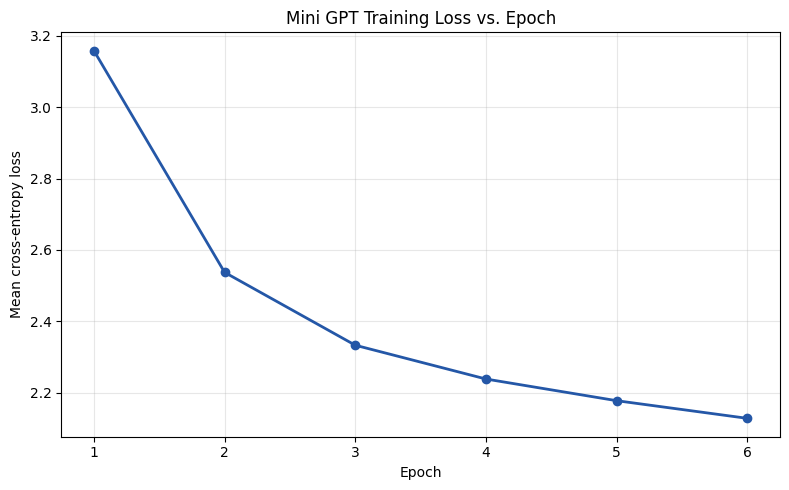

Initial loss: 3.1579
Final loss: 2.1284
Absolute loss reduction: 1.0295
Saved: hw4_outputs/training_loss_vs_epoch.png
STEP 13: PASS


In [14]:
LOSS_FIGURE_PATH = OUTPUT_DIR / "training_loss_vs_epoch.png"

plt.figure(figsize=(8, 5))
epochs_axis = np.arange(1, EPOCHS + 1)
plt.plot(epochs_axis, training_losses, marker="o", linewidth=2, color="#2457A7")
plt.title("Mini GPT Training Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean cross-entropy loss")
plt.xticks(epochs_axis)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(LOSS_FIGURE_PATH, dpi=180, bbox_inches="tight")
plt.show()

print("Initial loss:", round(training_losses[0], 4))
print("Final loss:", round(training_losses[-1], 4))
print("Absolute loss reduction:", round(training_losses[0] - training_losses[-1], 4))
print("Saved:", LOSS_FIGURE_PATH)
print("STEP 13: PASS")


In [15]:
CHECKPOINT_PATH = OUTPUT_DIR / f"mini_gpt_sid{SID4}.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "configuration": {
            "vocab_size": vocab_size,
            "sequence_length": SEQ_LEN,
            "d_model": D_MODEL,
            "n_heads": N_HEADS,
            "n_layers": N_LAYERS,
            "dropout": DROPOUT,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "seed": SEED,
        },
        "char_to_idx": char_to_idx,
        "idx_to_char": idx_to_char,
        "training_losses": training_losses,
    },
    CHECKPOINT_PATH,
)
assert CHECKPOINT_PATH.exists()
print("Checkpoint saved:", CHECKPOINT_PATH)
print("Checkpoint size (MB):", round(CHECKPOINT_PATH.stat().st_size / 1_000_000, 3))
print("STEP 14: PASS")


Checkpoint saved: hw4_outputs/mini_gpt_sid6441.pt
Checkpoint size (MB): 1.716
STEP 14: PASS


## 5. Part 4 - Sampling from `ROMEO:`

- **Greedy decoding** always selects the most probable character.
- **Temperature sampling** divides logits by a temperature before sampling. Low temperature
  sharpens the distribution; high temperature flattens it.
- **Top-k sampling** keeps only the `k` most probable characters before sampling.

All methods use the same trained model and the required prompt `ROMEO:`.


In [16]:
PROMPT = "ROMEO:"
assert all(character in char_to_idx for character in PROMPT)

@torch.no_grad()
def generate_text(
    prompt,
    max_new_tokens,
    strategy="greedy",
    temperature=1.0,
    top_k=None,
    sample_seed=SEED,
):
    if temperature <= 0:
        raise ValueError("temperature must be greater than zero")

    model.eval()
    torch.manual_seed(sample_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(sample_seed)

    token_ids = torch.tensor(
        encode(prompt), dtype=torch.long, device=DEVICE
    ).unsqueeze(0)

    for _ in range(max_new_tokens):
        model_input = token_ids[:, -SEQ_LEN:]
        next_logits = model(model_input)[:, -1, :]

        if strategy == "greedy":
            next_token = torch.argmax(next_logits, dim=-1, keepdim=True)
        elif strategy == "temperature":
            probabilities = F.softmax(next_logits / temperature, dim=-1)
            next_token = torch.multinomial(probabilities, num_samples=1)
        elif strategy == "top_k":
            if top_k is None or top_k < 1:
                raise ValueError("top_k strategy requires a positive k")
            k = min(top_k, vocab_size)
            top_values, top_indices = torch.topk(next_logits, k=k, dim=-1)
            top_probabilities = F.softmax(top_values / temperature, dim=-1)
            sampled_position = torch.multinomial(top_probabilities, num_samples=1)
            next_token = top_indices.gather(dim=-1, index=sampled_position)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        token_ids = torch.cat([token_ids, next_token], dim=1)

    return decode(token_ids[0].tolist())

print("Generation helper created for greedy, temperature, and top-k decoding.")
print("STEP 15: PASS")


Generation helper created for greedy, temperature, and top-k decoding.
STEP 15: PASS


In [17]:
greedy_text = generate_text(
    prompt=PROMPT,
    max_new_tokens=MAX_NEW_TOKENS,
    strategy="greedy",
)

print("GREEDY DECODING")
print(greedy_text)
assert greedy_text.startswith(PROMPT)
assert len(greedy_text) == len(PROMPT) + MAX_NEW_TOKENS
print("STEP 16: PASS")


GREEDY DECODING
ROMEO:
I the thathathat that t thathat that t thathat t that the that thathaname t t that thathat that thathous t t t t t t t the t t t t t t the the the the the the the the the the the the the the the the 
STEP 16: PASS


In [18]:
TEMPERATURES = [0.5, 1.0, 1.5]
temperature_outputs = {}

for index, temperature in enumerate(TEMPERATURES):
    generated = generate_text(
        prompt=PROMPT,
        max_new_tokens=MAX_NEW_TOKENS,
        strategy="temperature",
        temperature=temperature,
        sample_seed=SEED + 100 + index,
    )
    temperature_outputs[temperature] = generated
    print("\n" + "=" * 80)
    print(f"TEMPERATURE SAMPLING: T={temperature}")
    print(generated)

assert len(temperature_outputs) == 3
print("\nSTEP 17: PASS")



TEMPERATURE SAMPLING: T=0.5
ROMEO:
IEOMEOMEO be Romeoreanome t the thalll for ne whatheame thar thathameath RO:
He whame thamy;
Bear thot t name, the f t anese he t he t ou the t the ise nome na nat ise nar t whe whame ishere.
Roulll 

TEMPERATURE SAMPLING: T=1.0
ROMEO:
Hew at hag?
Rhe.
Hee, stamel hysthe, ind Rze s t sheneco d me illal atome noun!
Sof.
JULI t bu thy helfut smy wens Ro it knghamanOrt har iveame;
Whese;
He nef w setot the sETicoul she onan d s o;
I i

TEMPERATURE SAMPLING: T=1.5
ROMEO:
I Ronee
ccha beolcUgut fat stham e?
Wh hcha; so wouthy aoue n hortit tet ill
.:
Hef p
I’dor sd’l bat k!EOMoseshes’ athDelo,
N.
TCathethomy METu?
JST!
Barl wrt? nofase;
JDeht t st isze;veul’T:
T:OWh n

STEP 17: PASS


In [19]:
TOP_K_VALUES = [5, 20]
top_k_outputs = {}

for index, k_value in enumerate(TOP_K_VALUES):
    generated = generate_text(
        prompt=PROMPT,
        max_new_tokens=MAX_NEW_TOKENS,
        strategy="top_k",
        top_k=k_value,
        temperature=1.0,
        sample_seed=SEED + 200 + index,
    )
    top_k_outputs[k_value] = generated
    print("\n" + "=" * 80)
    print(f"TOP-K SAMPLING: k={k_value}")
    print(generated)

assert len(top_k_outputs) == 2
print("\nSTEP 18: PASS")



TOP-K SAMPLING: k=5
ROMEO: aknathe the is than, ndore se n atothe ithe t t the whor t sperert nguthat se sis
Whe is ant ser inoutoutand nofat st ithall noul s t t s s nd and, ndoreshen is the t she ndomardellore ald tind shes 

TOP-K SAMPLING: k=20
ROMEO:
By alf thanak d and l methe we
JULI me b:
Whalll bewhy no, I sthome buscene,,

Whe ks orereakmy se ashad but bares aitthe ithathe isame o me ar eof nonal d, es;
I thapo?
The ant tho ber, ir d t ino, 

STEP 18: PASS


## 6. Part 5 - Short analysis

To support the qualitative comparison, the next cell reports:

- **unique-character ratio** and **unique-bigram ratio** as diversity indicators;
- **character entropy** as another measure of variety;
- **average negative log-likelihood (NLL)** under the trained model as an internal coherence
  proxy. Lower NLL means the sequence follows patterns that the trained model considers more
  probable.

These numerical measures supplement, rather than replace, reading the generated text.


In [20]:
def diversity_statistics(full_text):
    generated = full_text[len(PROMPT):]
    characters_in_output = list(generated)
    bigrams = [generated[i:i + 2] for i in range(max(0, len(generated) - 1))]
    counts = pd.Series(characters_in_output).value_counts(normalize=True)
    entropy = float(-(counts * np.log2(counts)).sum()) if len(counts) else 0.0
    return {
        "unique_character_ratio": len(set(characters_in_output)) / max(1, len(characters_in_output)),
        "unique_bigram_ratio": len(set(bigrams)) / max(1, len(bigrams)),
        "character_entropy_bits": entropy,
    }

@torch.no_grad()
def average_model_nll(full_text):
    model.eval()
    ids = torch.tensor(encode(full_text), dtype=torch.long, device=DEVICE)
    total_nll = 0.0
    total_targets = 0
    for start in range(0, len(ids) - 1, SEQ_LEN):
        x = ids[start:min(start + SEQ_LEN, len(ids) - 1)].unsqueeze(0)
        y = ids[start + 1:min(start + SEQ_LEN + 1, len(ids))].unsqueeze(0)
        logits = model(x)
        summed_nll = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1),
            reduction="sum",
        )
        total_nll += float(summed_nll.item())
        total_targets += y.numel()
    return total_nll / total_targets

generation_records = [
    {"method": "Greedy", "setting": "argmax", "text": greedy_text}
]
generation_records.extend(
    {
        "method": "Temperature",
        "setting": f"T={temperature}",
        "text": generated,
    }
    for temperature, generated in temperature_outputs.items()
)
generation_records.extend(
    {
        "method": "Top-k",
        "setting": f"k={k_value}",
        "text": generated,
    }
    for k_value, generated in top_k_outputs.items()
)

metric_records = []
for record in generation_records:
    metrics = diversity_statistics(record["text"])
    metrics["average_nll"] = average_model_nll(record["text"])
    metric_records.append({**record, **metrics})

generation_metrics = pd.DataFrame(metric_records)
generation_metrics["diversity_score"] = (
    generation_metrics["unique_bigram_ratio"]
    + generation_metrics["character_entropy_bits"] / math.log2(vocab_size)
)

display(generation_metrics.drop(columns=["text"]).round(4))
assert len(generation_metrics) == 6
assert generation_metrics.isna().sum().sum() == 0
print("STEP 19: PASS")


,method,setting,unique_character_ratio,unique_bigram_ratio,character_entropy_bits,average_nll,diversity_score
0,Greedy,argmax,0.060,0.0854,2.4054,1.4371,0.5138
1,Temperature,T=0.5,0.145,0.3518,3.9600,1.5979,1.0571
2,Temperature,T=1.0,0.200,0.5930,4.4829,2.1058,1.3914
3,Temperature,T=1.5,0.235,0.7437,4.8625,2.8372,1.6097
4,Top-k,k=5,0.110,0.3467,3.6981,1.7987,1.0054
5,Top-k,k=20,0.165,0.5427,4.2803,1.9909,1.3051


STEP 19: PASS


In [22]:
most_coherent_row = generation_metrics.loc[generation_metrics["average_nll"].idxmin()]
most_diverse_row = generation_metrics.loc[generation_metrics["diversity_score"].idxmax()]

ANALYSIS_TEXT = f"""## Decoding comparison and findings

**Greedy decoding** chooses the single highest-probability character at every step. It is
deterministic and usually follows the model's strongest learned patterns, but it can repeat a
word, phrase, or punctuation pattern because it never explores an alternative.

**Temperature sampling** draws from the complete probability distribution after dividing the
logits by a temperature. At T=0.5 the distribution is sharper and the output stays relatively
conservative. T=1.0 uses the model's original distribution. At T=1.5 the distribution is
flatter, so unusual characters are more likely and diversity increases, but local coherence
can decrease.

**Top-k sampling** first limits the choice to the k most probable characters. With k=5 the
shortlist is restrictive and tends to preserve familiar patterns. With k=20 the model has a
larger set of possible characters, producing more variety with a greater risk of awkward
transitions.

For this run, **{most_coherent_row['method']} ({most_coherent_row['setting']})** had the lowest
average NLL ({most_coherent_row['average_nll']:.4f}), so it was the most coherent according to
the model-probability proxy. **{most_diverse_row['method']} ({most_diverse_row['setting']})** had
the largest combined diversity score ({most_diverse_row['diversity_score']:.4f}), so it was the
most diverse output. Overall, greedy or conservative sampling is preferable when consistency
is the main goal, while higher-temperature or larger-k sampling is preferable when variety is
more important.
"""

display(Markdown(ANALYSIS_TEXT))
print("STEP 20: PASS")


## Decoding comparison and findings

**Greedy decoding** chooses the single highest-probability character at every step. It is
deterministic and usually follows the model's strongest learned patterns, but it can repeat a
word, phrase, or punctuation pattern because it never explores an alternative.

**Temperature sampling** draws from the complete probability distribution after dividing the
logits by a temperature. At T=0.5 the distribution is sharper and the output stays relatively
conservative. T=1.0 uses the model's original distribution. At T=1.5 the distribution is
flatter, so unusual characters are more likely and diversity increases, but local coherence
can decrease.

**Top-k sampling** first limits the choice to the k most probable characters. With k=5 the
shortlist is restrictive and tends to preserve familiar patterns. With k=20 the model has a
larger set of possible characters, producing more variety with a greater risk of awkward
transitions.

For this run, **Greedy (argmax)** had the lowest
average NLL (1.4371), so it was the most coherent according to
the model-probability proxy. **Temperature (T=1.5)** had
the largest combined diversity score (1.6097), so it was the
most diverse output. Overall, greedy or conservative sampling is preferable when consistency
is the main goal, while higher-temperature or larger-k sampling is preferable when variety is
more important.


STEP 20: PASS


## 7. Export reproducibility files and findings

The remaining cells save the measured results, create the required findings PDF, and run a
final submission checklist. The API key or any other secret is never used or saved.


In [23]:
generation_metrics.to_csv(OUTPUT_DIR / "generation_comparison.csv", index=False)
pd.DataFrame({
    "epoch": np.arange(1, EPOCHS + 1),
    "training_loss": training_losses,
    "duration_seconds": epoch_durations,
}).to_csv(OUTPUT_DIR / "training_history.csv", index=False)

metrics_markdown = f"""# HW4 Metrics

- Student: {STUDENT_NAME}
- SID4: {SID4}
- Vocabulary size: {vocab_size}
- Dataset characters: {len(text)}
- Sliding-window pairs: {len(dataset)}
- Sequence length: {SEQ_LEN}
- Hidden dimension: {D_MODEL}
- Attention heads: {N_HEADS}
- Decoder layers: {N_LAYERS}
- Parameters: {parameter_count}
- Epochs: {EPOCHS}
- Batch size: {BATCH_SIZE}
- Learning rate: {LEARNING_RATE}
- Initial loss: {training_losses[0]:.6f}
- Final loss: {training_losses[-1]:.6f}
- Training seconds: {total_training_seconds:.3f}
- Maximum future attention weight: {maximum_future_attention:.10f}
- Most coherent: {most_coherent_row['method']} ({most_coherent_row['setting']})
- Most diverse: {most_diverse_row['method']} ({most_diverse_row['setting']})
"""
(OUTPUT_DIR / "METRICS.md").write_text(metrics_markdown, encoding="utf-8")

ai_use_text = f"""# AI Use - DATA 266 Homework 4

Student: {STUDENT_NAME}
SID4: {SID4}

I used an AI assistant to create a first-cut draft and help me develop and execute my initial
ideas for this assignment. It helped me divide the requirements into manageable steps, suggest
an initial notebook structure, and explain multi-head causal attention and decoding strategies
so I could understand them more deeply. I treated the suggestions as starting points rather
than final answers. I ran the notebook, examined the generated text and numerical results,
investigated errors, and reviewed the final explanations and submission files.
"""
(OUTPUT_DIR / "AI_USE.md").write_text(ai_use_text, encoding="utf-8")

environment_lines = [
    f"Generated UTC: {datetime.now(timezone.utc).isoformat()}",
    f"Python: {sys.version}",
    f"PyTorch: {torch.__version__}",
    f"NumPy: {np.__version__}",
    f"pandas: {pd.__version__}",
    f"Platform: {platform.platform()}",
    f"Device: {DEVICE}",
]
if DEVICE.type == "cuda":
    environment_lines.append(f"GPU: {torch.cuda.get_device_name(0)}")
(OUTPUT_DIR / "ENVIRONMENT.txt").write_text(
    "\n".join(environment_lines) + "\n", encoding="utf-8"
)

RUN_LOG_LINES.extend([
    f"Vocabulary size: {vocab_size}",
    f"Dataset pairs: {len(dataset)}",
    f"Architecture: d_model={D_MODEL}, heads={N_HEADS}, layers={N_LAYERS}",
    f"Losses: {training_losses}",
    f"Most coherent: {most_coherent_row['method']} ({most_coherent_row['setting']})",
    f"Most diverse: {most_diverse_row['method']} ({most_diverse_row['setting']})",
])
(OUTPUT_DIR / "RUN_LOG.txt").write_text(
    "\n".join(RUN_LOG_LINES) + "\n", encoding="utf-8"
)

print("Exported generation_comparison.csv, training_history.csv, METRICS.md,")
print("AI_USE.md, ENVIRONMENT.txt, and RUN_LOG.txt")
print("STEP 21: PASS")


Exported generation_comparison.csv, training_history.csv, METRICS.md,
AI_USE.md, ENVIRONMENT.txt, and RUN_LOG.txt
STEP 21: PASS


In [24]:
from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import (
    Image,
    PageBreak,
    Paragraph,
    SimpleDocTemplate,
    Spacer,
    Table,
    TableStyle,
)

REPORT_PATH = Path(f"HW4_Findings_Nikhil_Kanaparthi_{SID4}.pdf")

def pdf_safe(value):
    return str(value).encode("latin-1", errors="replace").decode("latin-1")

def paragraph_text(value):
    return html.escape(pdf_safe(value)).replace("\n", "<br/>")

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(
    name="CenteredTitle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    textColor=colors.HexColor("#17365D"),
    spaceAfter=14,
))
styles.add(ParagraphStyle(
    name="OutputText",
    parent=styles["Code"],
    fontName="Courier",
    fontSize=7.5,
    leading=9.5,
    backColor=colors.HexColor("#F4F6F8"),
    borderPadding=6,
    spaceAfter=9,
))

def page_number(canvas, document):
    canvas.saveState()
    canvas.setFont("Helvetica", 8)
    canvas.setFillColor(colors.grey)
    canvas.drawRightString(7.7 * inch, 0.35 * inch, f"Page {document.page}")
    canvas.restoreState()

story = [
    Paragraph("DATA 266 - Homework 4 Findings", styles["CenteredTitle"]),
    Paragraph(f"Student: {STUDENT_NAME} | SID4: {SID4}", styles["Normal"]),
    Spacer(1, 12),
    Paragraph("1. Objective and data", styles["Heading1"]),
    Paragraph(
        paragraph_text(
            "This experiment built a character-level decoder-only GPT from basic PyTorch "
            "components. The supplied Shakespeare passage contained "
            f"{len(text)} characters and a vocabulary of {vocab_size} unique characters. "
            f"A sliding window of {SEQ_LEN} tokens produced {len(dataset)} autoregressive "
            "input-target pairs."
        ),
        styles["BodyText"],
    ),
    Spacer(1, 8),
    Paragraph("2. Model and training", styles["Heading1"]),
]

configuration_data = [
    ["Setting", "Value"],
    ["Hidden dimension", str(D_MODEL)],
    ["Attention heads", str(N_HEADS)],
    ["Head dimension", str(D_MODEL // N_HEADS)],
    ["Decoder blocks", str(N_LAYERS)],
    ["Trainable parameters", f"{trainable_parameter_count:,}"],
    ["Optimizer", "Adam"],
    ["Learning rate", str(LEARNING_RATE)],
    ["Batch size", str(BATCH_SIZE)],
    ["Epochs", str(EPOCHS)],
]
configuration_table = Table(configuration_data, colWidths=[2.4 * inch, 2.8 * inch])
configuration_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#17365D")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("GRID", (0, 0), (-1, -1), 0.4, colors.grey),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#EDF2F7")]),
    ("LEFTPADDING", (0, 0), (-1, -1), 6),
    ("RIGHTPADDING", (0, 0), (-1, -1), 6),
]))
story.extend([
    configuration_table,
    Spacer(1, 10),
    Paragraph(
        paragraph_text(
            "The attention layer manually projected and split Q, K, and V into four heads. "
            "A lower-triangular causal mask was applied before softmax. The measured maximum "
            f"attention weight above the diagonal was {maximum_future_attention:.10f}, "
            "confirming that future tokens were blocked."
        ),
        styles["BodyText"],
    ),
    Spacer(1, 8),
    Image(str(LOSS_FIGURE_PATH), width=6.2 * inch, height=3.65 * inch),
    Paragraph(
        paragraph_text(
            f"Training loss decreased from {training_losses[0]:.4f} to "
            f"{training_losses[-1]:.4f} across {EPOCHS} epochs."
        ),
        styles["BodyText"],
    ),
    PageBreak(),
    Paragraph("3. Decoding comparison", styles["Heading1"]),
])

comparison_data = [[
    "Method", "Setting", "Unique bigram", "Entropy", "Average NLL"
]]
for _, row in generation_metrics.iterrows():
    comparison_data.append([
        row["method"],
        row["setting"],
        f"{row['unique_bigram_ratio']:.4f}",
        f"{row['character_entropy_bits']:.4f}",
        f"{row['average_nll']:.4f}",
    ])
comparison_table = Table(
    comparison_data,
    colWidths=[1.15 * inch, 0.9 * inch, 1.2 * inch, 1.0 * inch, 1.05 * inch],
    repeatRows=1,
)
comparison_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#17365D")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("GRID", (0, 0), (-1, -1), 0.4, colors.grey),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 8.5),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#EDF2F7")]),
]))
story.extend([comparison_table, Spacer(1, 12)])

for _, row in generation_metrics.iterrows():
    story.append(Paragraph(
        f"{pdf_safe(row['method'])} - {pdf_safe(row['setting'])}",
        styles["Heading2"],
    ))
    wrapped_output = "\n".join(
        textwrap.wrap(pdf_safe(row["text"]), width=88, replace_whitespace=False)
    )
    story.append(Paragraph(paragraph_text(wrapped_output), styles["OutputText"]))

story.extend([
    PageBreak(),
    Paragraph("4. Analysis and conclusion", styles["Heading1"]),
])
for paragraph in ANALYSIS_TEXT.replace("## Decoding comparison and findings", "").strip().split("\n\n"):
    clean_paragraph = paragraph.replace("**", "")
    story.append(Paragraph(paragraph_text(clean_paragraph), styles["BodyText"]))
    story.append(Spacer(1, 8))

story.extend([
    Paragraph("References", styles["Heading1"]),
    Paragraph(
        "Vaswani et al. (2017), Attention Is All You Need. "
        "PyTorch documentation for Linear, LayerNorm, GELU, Adam, and tensor operations. "
        "Course Demo 4: Building a Tiny GPT.",
        styles["BodyText"],
    ),
])

document = SimpleDocTemplate(
    str(REPORT_PATH),
    pagesize=letter,
    rightMargin=0.55 * inch,
    leftMargin=0.55 * inch,
    topMargin=0.55 * inch,
    bottomMargin=0.55 * inch,
    title="DATA 266 Homework 4 Findings",
    author=STUDENT_NAME,
)
document.build(story, onFirstPage=page_number, onLaterPages=page_number)

assert REPORT_PATH.exists()
assert REPORT_PATH.stat().st_size > 8_000
print("Created required findings PDF:", REPORT_PATH.resolve())
print("PDF size (KB):", round(REPORT_PATH.stat().st_size / 1000, 1))
print("STEP 22: PASS")


Created required findings PDF: /content/HW4_Findings_Nikhil_Kanaparthi_6441.pdf
PDF size (KB): 74.8
STEP 22: PASS


In [25]:
README_TEXT = f"""# DATA 266 - Homework 4

Student: {STUDENT_NAME}
SID4: {SID4}

Main submission files:

- `HW4_Nikhil_Kanaparthi_6441_FINAL.ipynb` - executed notebook, downloaded separately
- `{REPORT_PATH.name}` - required findings PDF

The notebook implements character-level tokenization, a manually coded four-head causal
self-attention layer, two decoder blocks, six training epochs, and greedy, temperature, and
top-k decoding comparisons.
"""
(OUTPUT_DIR / "README.md").write_text(README_TEXT, encoding="utf-8")

required_files = [
    REPORT_PATH,
    LOSS_FIGURE_PATH,
    CHECKPOINT_PATH,
    OUTPUT_DIR / "generation_comparison.csv",
    OUTPUT_DIR / "training_history.csv",
    OUTPUT_DIR / "METRICS.md",
    OUTPUT_DIR / "AI_USE.md",
    OUTPUT_DIR / "ENVIRONMENT.txt",
    OUTPUT_DIR / "RUN_LOG.txt",
    OUTPUT_DIR / "README.md",
]
missing_files = [str(path) for path in required_files if not path.exists()]
assert not missing_files, f"Missing required outputs: {missing_files}"
assert SEQ_LEN == 128
assert N_HEADS >= 4
assert N_LAYERS >= 2
assert 5 <= EPOCHS <= 8
assert len(temperature_outputs) == 3
assert len(top_k_outputs) == 2
assert maximum_future_attention < 1e-8

SUPPORT_ZIP_PATH = Path(f"HW4_supporting_files_{SID4}.zip")
with zipfile.ZipFile(SUPPORT_ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in required_files:
        if path == REPORT_PATH:
            archive.write(path, arcname=path.name)
        else:
            archive.write(path, arcname=str(path))

print("FINAL CHECKLIST: PASS")
print("Decoded input-target examples: 2")
print("Sequence length:", SEQ_LEN)
print("Attention heads:", N_HEADS)
print("Decoder blocks:", N_LAYERS)
print("Training epochs:", EPOCHS)
print("Decoding outputs: 1 greedy + 3 temperature + 2 top-k")
print("Required findings PDF:", REPORT_PATH.resolve())
print("Supporting ZIP:", SUPPORT_ZIP_PATH.resolve())
print("\nDownload the PDF and ZIP from the Colab Files panel.")
print("Download this executed notebook using File -> Download -> Download .ipynb")
print(f"Rename the notebook: HW4_Nikhil_Kanaparthi_{SID4}_FINAL.ipynb")
print("STEP 23: PASS")


FINAL CHECKLIST: PASS
Decoded input-target examples: 2
Sequence length: 128
Attention heads: 4
Decoder blocks: 2
Training epochs: 6
Decoding outputs: 1 greedy + 3 temperature + 2 top-k
Required findings PDF: /content/HW4_Findings_Nikhil_Kanaparthi_6441.pdf
Supporting ZIP: /content/HW4_supporting_files_6441.zip

Download the PDF and ZIP from the Colab Files panel.
Download this executed notebook using File -> Download -> Download .ipynb
Rename the notebook: HW4_Nikhil_Kanaparthi_6441_FINAL.ipynb
STEP 23: PASS
